<a href="https://colab.research.google.com/github/VipersDiapers/nvidia-equity-research/blob/main/NVIDIA_Equity_Research_Valuation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NVIDIA (NVDA) Equity Research & Valuation Project
**Python + Financial Statement Analysis + DCF + Scenario Analysis + Trading/Performance Review**

This project analyzes NVIDIA as an equity-research case study. It combines:
- market-price analysis,
- operating and financial-statement trends,
- business/segment analysis,
- a five-year discounted cash flow model,
- bear/base/bull scenarios,
- valuation sensitivity,
- and an investment-thesis framework.

> **Important:** Historical figures are sourced from NVIDIA investor-relations / SEC filings. Forecasts are analyst assumptions for educational purposes, not investment advice.

## 1. Project setup

Run this notebook in **Google Colab**. The first code cell installs the packages used in the project.

The live-market sections pull current data when the notebook is run, so the charts can refresh automatically.

In [1]:
!pip -q install yfinance pandas numpy matplotlib scipy

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.optimize import newton

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

## 2. Historical stock-price analysis

This section downloads NVIDIA and S&P 500 price history and calculates:
- cumulative return,
- annualized volatility,
- maximum drawdown,
- 50-day and 200-day moving averages,
- and relative performance.

**Why this matters:** Equity research should distinguish business fundamentals from market behavior. A great company can still be a poor investment if valuation is too high.

In [3]:
start_date = "2021-01-01"
tickers = ["NVDA", "SPY"]

prices = yf.download(tickers, start=start_date, auto_adjust=True, progress=False)["Close"].dropna()
returns = prices.pct_change().dropna()

summary = pd.DataFrame({
    "Cumulative Return": (prices.iloc[-1] / prices.iloc[0]) - 1,
    "Annualized Volatility": returns.std() * np.sqrt(252)
})

def max_drawdown(series):
    running_max = series.cummax()
    drawdown = series / running_max - 1
    return drawdown.min()

summary["Max Drawdown"] = [max_drawdown(prices[c]) for c in prices.columns]
summary

,Cumulative Return,Annualized Volatility,Max Drawdown
Ticker,,,
NVDA,16.28,0.51,-0.66
SPY,1.24,0.17,-0.24


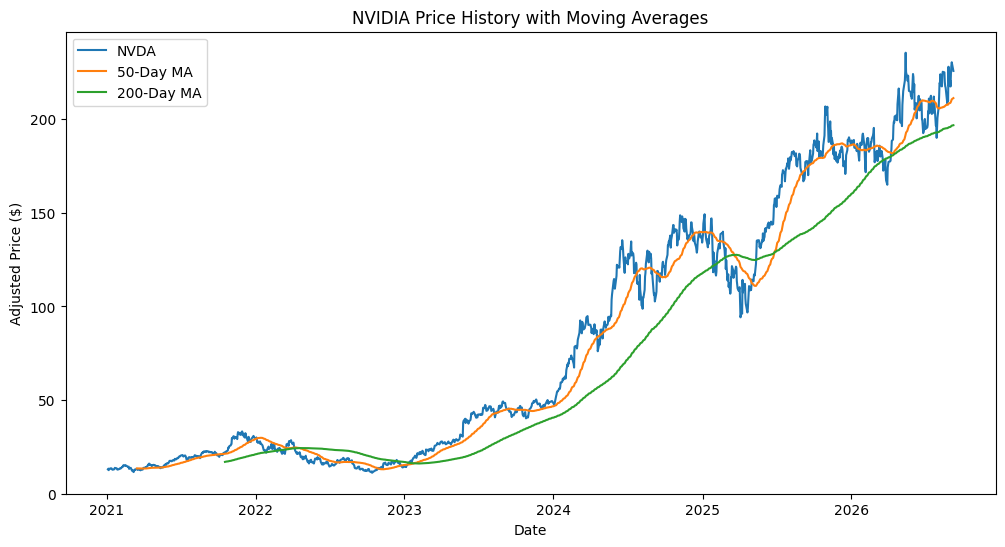

In [4]:
nvda = prices["NVDA"].copy()
ma50 = nvda.rolling(50).mean()
ma200 = nvda.rolling(200).mean()

plt.figure(figsize=(12,6))
plt.plot(nvda.index, nvda, label="NVDA")
plt.plot(ma50.index, ma50, label="50-Day MA")
plt.plot(ma200.index, ma200, label="200-Day MA")
plt.title("NVIDIA Price History with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Adjusted Price ($)")
plt.legend()
plt.show()

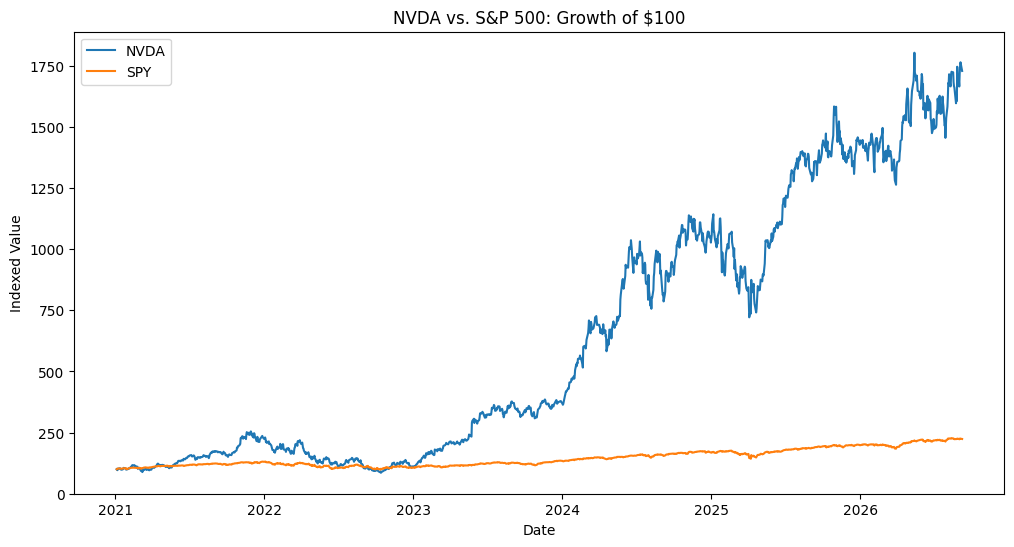

In [5]:
normalized = prices / prices.iloc[0] * 100

plt.figure(figsize=(12,6))
plt.plot(normalized.index, normalized["NVDA"], label="NVDA")
plt.plot(normalized.index, normalized["SPY"], label="SPY")
plt.title("NVDA vs. S&P 500: Growth of $100")
plt.xlabel("Date")
plt.ylabel("Indexed Value")
plt.legend()
plt.show()

## 3. Historical financial performance

NVIDIA reported FY2026 revenue of **$215.938B**, operating income of **$130.387B**, and net income of **$120.067B**. FY2026 operating cash flow was **$102.718B**, and capital expenditures were approximately **$6.1B**.

The company then reported Q2 FY2027 revenue of **$96.221B**, including **$89.0B** of Data Center revenue, with a **75.0% GAAP gross margin**.

The table below uses reported annual data to show the magnitude of NVIDIA's recent earnings expansion.

In [6]:
historicals = pd.DataFrame({
    "Fiscal Year": ["FY24", "FY25", "FY26"],
    "Revenue ($B)": [60.922, 130.497, 215.938],
    "Net Income ($B)": [29.760, 72.880, 120.067],
    "Operating Cash Flow ($B)": [28.090, 64.089, 102.718],
    "Capex ($B)": [1.069, 3.400, 6.100]
})
historicals["FCF ($B)"] = historicals["Operating Cash Flow ($B)"] - historicals["Capex ($B)"]
historicals["Revenue Growth"] = historicals["Revenue ($B)"].pct_change()
historicals["Net Margin"] = historicals["Net Income ($B)"] / historicals["Revenue ($B)"]
historicals

,Fiscal Year,Revenue ($B),Net Income ($B),Operating Cash Flow ($B),Capex ($B),FCF ($B),Revenue Growth,Net Margin
0,FY24,60.92,29.76,28.09,1.07,27.02,NaN,0.49
1,FY25,130.50,72.88,64.09,3.40,60.69,1.14,0.56
2,FY26,215.94,120.07,102.72,6.10,96.62,0.65,0.56


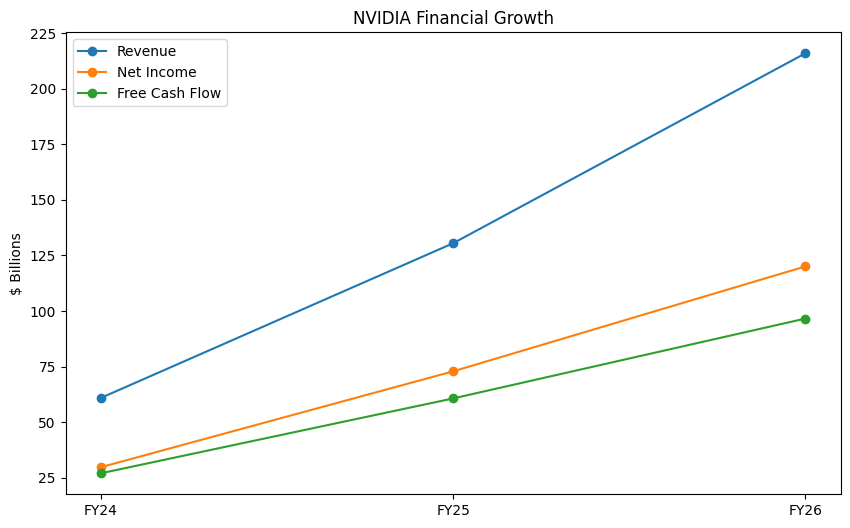

In [7]:
plt.figure(figsize=(10,6))
plt.plot(historicals["Fiscal Year"], historicals["Revenue ($B)"], marker="o", label="Revenue")
plt.plot(historicals["Fiscal Year"], historicals["Net Income ($B)"], marker="o", label="Net Income")
plt.plot(historicals["Fiscal Year"], historicals["FCF ($B)"], marker="o", label="Free Cash Flow")
plt.title("NVIDIA Financial Growth")
plt.ylabel("$ Billions")
plt.legend()
plt.show()

## 4. Business mix and operating thesis

NVIDIA's growth is increasingly driven by AI infrastructure. In Q2 FY2027:
- Total revenue: **$96.221B**
- Data Center revenue: **$89.0B**
- Data Center YoY growth: **117%**
- GAAP gross margin: **75.0%**

### Core thesis drivers
1. **Accelerated computing adoption:** AI workloads increasingly require GPU-heavy infrastructure.
2. **Platform economics:** NVIDIA sells more than chips; its ecosystem includes networking, systems, CUDA software, and AI infrastructure.
3. **Data Center concentration:** The same segment driving exceptional growth also creates concentration risk.
4. **Product-cycle execution:** Blackwell and Vera Rubin adoption are major determinants of future growth.
5. **Supply/geopolitical exposure:** Export restrictions and dependence on Asian semiconductor supply chains remain material risks.

In [8]:
q2_revenue = 96.221
q2_dc = 89.0
dc_mix = q2_dc / q2_revenue

print(f"Q2 FY27 Data Center mix: {dc_mix:.1%}")

Q2 FY27 Data Center mix: 92.5%


## 5. Ratio and quality-of-earnings analysis

The following ratios help assess profitability, cash conversion, and balance-sheet flexibility.

This section deliberately avoids pretending that every ratio is equally important. For NVIDIA, margins, free-cash-flow conversion, revenue growth, and capital intensity are especially relevant.

In [9]:
fy26_revenue = 215.938
fy26_net_income = 120.067
fy26_ocf = 102.718
fy26_capex = 6.1
fy26_fcf = fy26_ocf - fy26_capex

ratios = pd.Series({
    "Net Margin": fy26_net_income / fy26_revenue,
    "OCF Margin": fy26_ocf / fy26_revenue,
    "FCF Margin": fy26_fcf / fy26_revenue,
    "Capex / Revenue": fy26_capex / fy26_revenue,
})
ratios.to_frame("FY26")

,FY26
Net Margin,0.56
OCF Margin,0.48
FCF Margin,0.45
Capex / Revenue,0.03


## 6. DCF valuation

### Method
The DCF starts with FY2026 free cash flow:

**FCF = Operating Cash Flow − Capital Expenditures**

FY2026:
- Operating cash flow = **$102.718B**
- Capex ≈ **$6.1B**
- Base FCF ≈ **$96.618B**

This model then forecasts five years of FCF, discounts each year's cash flow using WACC, calculates terminal value using the Gordon Growth Method, and adjusts enterprise value for net cash/debt.

### Base-case assumptions
The assumptions below are intentionally visible and editable. A serious project should make assumptions explicit rather than hiding them inside code.

In [10]:
base_fcf = 96.618  # $B

assumptions = {
    "FCF Growth Y1": 0.45,
    "FCF Growth Y2": 0.32,
    "FCF Growth Y3": 0.24,
    "FCF Growth Y4": 0.18,
    "FCF Growth Y5": 0.14,
    "WACC": 0.105,
    "Terminal Growth": 0.04,
    "Cash + Marketable Debt Securities": 56.586,  # $B, Jul. 26 2026
    "Debt": 33.366,                                # $B, carrying value
    "Shares Outstanding": 24.1                     # B shares, Aug. 21 2026
}
assumptions

{'FCF Growth Y1': 0.45,
 'FCF Growth Y2': 0.32,
 'FCF Growth Y3': 0.24,
 'FCF Growth Y4': 0.18,
 'FCF Growth Y5': 0.14,
 'WACC': 0.105,
 'Terminal Growth': 0.04,
 'Cash + Marketable Debt Securities': 56.586,
 'Debt': 33.366,
 'Shares Outstanding': 24.1}

In [11]:
growth_rates = [
    assumptions["FCF Growth Y1"],
    assumptions["FCF Growth Y2"],
    assumptions["FCF Growth Y3"],
    assumptions["FCF Growth Y4"],
    assumptions["FCF Growth Y5"],
]

forecast = []
fcf = base_fcf
for year, growth in enumerate(growth_rates, start=1):
    fcf *= (1 + growth)
    forecast.append({"Year": year, "Growth": growth, "FCF ($B)": fcf})

forecast_df = pd.DataFrame(forecast)
forecast_df

,Year,Growth,FCF ($B)
0,1,0.45,140.10
1,2,0.32,184.93
2,3,0.24,229.31
3,4,0.18,270.58
4,5,0.14,308.47


In [12]:
wacc = assumptions["WACC"]
g = assumptions["Terminal Growth"]

forecast_df["Discount Factor"] = 1 / (1 + wacc) ** forecast_df["Year"]
forecast_df["PV of FCF ($B)"] = forecast_df["FCF ($B)"] * forecast_df["Discount Factor"]

terminal_fcf = forecast_df.iloc[-1]["FCF ($B)"] * (1 + g)
terminal_value = terminal_fcf / (wacc - g)
pv_terminal = terminal_value / (1 + wacc) ** 5

enterprise_value = forecast_df["PV of FCF ($B)"].sum() + pv_terminal
net_cash = assumptions["Cash + Marketable Debt Securities"] - assumptions["Debt"]
equity_value = enterprise_value + net_cash
implied_share_price = equity_value / assumptions["Shares Outstanding"]

valuation = pd.Series({
    "PV of Forecast FCF ($B)": forecast_df["PV of FCF ($B)"].sum(),
    "PV of Terminal Value ($B)": pv_terminal,
    "Enterprise Value ($B)": enterprise_value,
    "Net Cash ($B)": net_cash,
    "Equity Value ($B)": equity_value,
    "Implied Share Price ($)": implied_share_price
})
valuation.to_frame("Base Case")

,Base Case
PV of Forecast FCF ($B),816.92
PV of Terminal Value ($B),"2,995.83"
Enterprise Value ($B),"3,812.75"
Net Cash ($B),23.22
Equity Value ($B),"3,835.97"
Implied Share Price ($),159.17


### DCF interpretation

A DCF is **not** a machine that produces the "correct" stock price. Its usefulness comes from understanding which assumptions must be true to justify a valuation.

For NVIDIA, the most sensitive assumptions are:
- the rate at which AI infrastructure demand normalizes,
- long-run FCF margins,
- WACC,
- and terminal growth.

That is why sensitivity analysis is required.

## 7. Bear / Base / Bull scenarios

In [13]:
def run_dcf(base_fcf, growth_rates, wacc, terminal_growth, net_cash, shares):
    fcf = base_fcf
    pv_sum = 0
    for i, gr in enumerate(growth_rates, start=1):
        fcf *= (1 + gr)
        pv_sum += fcf / (1 + wacc) ** i
    tv = fcf * (1 + terminal_growth) / (wacc - terminal_growth)
    pv_tv = tv / (1 + wacc) ** 5
    ev = pv_sum + pv_tv
    eq = ev + net_cash
    return eq / shares

scenarios = {
    "Bear": {
        "growth": [0.30, 0.22, 0.16, 0.12, 0.08],
        "wacc": 0.115,
        "g": 0.03
    },
    "Base": {
        "growth": [0.45, 0.32, 0.24, 0.18, 0.14],
        "wacc": 0.105,
        "g": 0.04
    },
    "Bull": {
        "growth": [0.55, 0.40, 0.30, 0.22, 0.16],
        "wacc": 0.095,
        "g": 0.045
    }
}

scenario_results = {}
for name, s in scenarios.items():
    scenario_results[name] = run_dcf(
        base_fcf,
        s["growth"],
        s["wacc"],
        s["g"],
        net_cash,
        assumptions["Shares Outstanding"]
    )

pd.Series(scenario_results, name="Implied Share Price ($)").to_frame()

,Implied Share Price ($)
Bear,89.33
Base,159.17
Bull,254.76


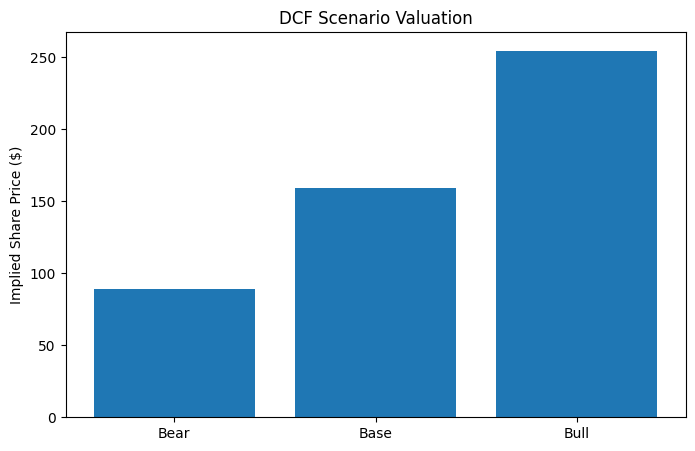

In [14]:
plt.figure(figsize=(8,5))
plt.bar(scenario_results.keys(), scenario_results.values())
plt.title("DCF Scenario Valuation")
plt.ylabel("Implied Share Price ($)")
plt.show()

## 8. WACC / terminal-growth sensitivity table

In [15]:
wacc_range = [0.09, 0.095, 0.10, 0.105, 0.11, 0.115, 0.12]
g_range = [0.025, 0.03, 0.035, 0.04, 0.045]

sensitivity = pd.DataFrame(index=[f"{w:.1%}" for w in wacc_range],
                           columns=[f"{g:.1%}" for g in g_range])

for w in wacc_range:
    for tg in g_range:
        sensitivity.loc[f"{w:.1%}", f"{tg:.1%}"] = run_dcf(
            base_fcf,
            growth_rates,
            w,
            tg,
            net_cash,
            assumptions["Shares Outstanding"]
        )

sensitivity.astype(float).round(2)

,2.5%,3.0%,3.5%,4.0%,4.5%
9.0%,167.56,179.18,192.92,209.41,229.56
9.5%,154.91,164.70,176.11,189.60,205.79
10.0%,143.97,152.30,161.90,173.11,186.36
10.5%,134.40,141.56,149.73,159.17,170.18
11.0%,125.97,132.17,139.20,147.23,156.50
11.5%,118.49,123.90,129.99,136.89,144.78
12.0%,111.80,116.56,121.88,127.86,134.64


## 9. Comparable-company framework

For a live comp table, this section pulls market data for NVIDIA and selected semiconductor / AI-infrastructure peers.

**Important:** Automated market-data fields can be missing or inconsistent. Before publishing the final project, reconcile key multiples to a reliable source or company filings.

In [16]:
peer_tickers = ["NVDA", "AMD", "AVGO", "INTC", "QCOM", "MRVL"]

rows = []
for ticker in peer_tickers:
    t = yf.Ticker(ticker)
    info = t.info
    rows.append({
        "Ticker": ticker,
        "Market Cap ($B)": info.get("marketCap", np.nan) / 1e9 if info.get("marketCap") else np.nan,
        "Trailing P/E": info.get("trailingPE", np.nan),
        "Forward P/E": info.get("forwardPE", np.nan),
        "EV/EBITDA": info.get("enterpriseToEbitda", np.nan),
        "Price/Sales": info.get("priceToSalesTrailing12Months", np.nan),
        "Gross Margin": info.get("grossMargins", np.nan),
        "Operating Margin": info.get("operatingMargins", np.nan),
    })

comps = pd.DataFrame(rows).set_index("Ticker")
comps

,Market Cap ($B),Trailing P/E,Forward P/E,EV/EBITDA,Price/Sales,Gross Margin,Operating Margin
Ticker,,,,,,,
NVDA,"5,450.70",28.57,14.55,26.91,17.99,0.75,0.66
AMD,825.61,129.02,32.60,85.42,19.99,0.56,0.17
AVGO,"1,753.45",47.01,19.01,34.43,19.68,0.76,0.54
INTC,552.24,NaN,51.16,33.45,9.68,0.39,0.12
QCOM,185.94,19.87,17.04,15.82,4.22,0.54,0.19
MRVL,202.58,74.64,33.54,69.82,21.44,0.52,0.17


## 10. Risk framework

### Key risks
- **Valuation compression:** Even strong earnings can produce weak stock returns if the multiple contracts.
- **AI capex normalization:** Hyperscaler and AI-lab infrastructure spending may eventually decelerate.
- **Customer concentration:** Large cloud/platform customers account for substantial infrastructure demand.
- **Export controls / China:** Restrictions can constrain addressable markets and create inventory/product-design issues.
- **Supply chain:** NVIDIA relies heavily on external foundries, packaging, memory, and systems partners.
- **Competition:** AMD, custom accelerators, ASICs, and hyperscaler-designed silicon can pressure share or pricing.
- **Execution risk:** Rapid platform transitions require tight supply, software, networking, and customer deployment execution.

## 11. Investment Thesis

### Base Case

My base case assumes NVIDIA remains the leader in accelerated computing and AI infrastructure, but that its current extraordinary growth rate gradually normalizes as the company becomes larger. I forecast free cash flow growth of 45%, 32%, 24%, 18%, and 14% over the next five years. Using a 10.5% WACC and 4.0% terminal growth rate, my DCF produces an implied value of approximately **$159 per share**.

I believe this represents a reasonable base case because it still assumes substantial long-term growth while recognizing that NVIDIA cannot maintain its recent growth rates indefinitely.

### Bull Case

The bull case assumes AI infrastructure spending remains exceptionally strong, NVIDIA maintains its competitive advantage in accelerated computing, and high margins and free cash flow generation persist longer than expected. Under more aggressive growth assumptions and a lower discount rate, my DCF produces an implied value of approximately **$255 per share**.

The main drivers of this scenario would be continued hyperscaler AI investment, sustained Data Center demand, continued platform leadership, and limited erosion of NVIDIA's pricing power.

### Bear Case

The bear case assumes AI infrastructure investment normalizes more quickly, competition increases, customers increasingly develop custom silicon, and NVIDIA experiences pressure on growth and margins. Under these assumptions, my model produces an implied value of approximately **$90 per share**.

Major downside risks include slowing AI capital expenditures, customer concentration, semiconductor cyclicality, competition, export restrictions, and valuation multiple compression.

### Valuation & Final View

My analysis leads me to a **cautiously bullish view of NVIDIA's underlying business, but a more cautious view of the stock's valuation**.

NVIDIA has exceptional profitability, free cash flow generation, and exposure to the structural growth of AI infrastructure. Its financial performance and competitive position justify a premium valuation relative to many semiconductor companies.

However, my base-case DCF value of approximately **$159 per share** is substantially below the current market valuation. The sensitivity analysis also shows that reaching significantly higher valuations requires increasingly favorable assumptions regarding the discount rate, terminal growth, or future free cash flow.

Therefore, the key takeaway from my analysis is not that NVIDIA is a weak company. Rather, **NVIDIA's current valuation already reflects significant expectations for future growth**. For the stock to generate substantial upside from current levels, the company will likely need to sustain exceptional AI-driven growth and profitability for longer than my base case assumes.

### Key Takeaway

**Exceptional business quality does not necessarily equal an undervalued stock.** My valuation suggests that NVIDIA's long-term fundamentals remain compelling, while its current market valuation leaves less room for execution mistakes or a faster-than-expected normalization in AI infrastructure growth.


## 12. Sources

Primary sources used in the project:
- NVIDIA FY2026 earnings release / investor relations
- NVIDIA FY2026 Form 10-K
- NVIDIA Q2 FY2027 earnings release
- NVIDIA Q2 FY2027 Form 10-Q
- Yahoo Finance via `yfinance` for live market-data sections

### Source links
- https://investor.nvidia.com/
- https://www.sec.gov/edgar/browse/?CIK=1045810&owner=exclude
- https://finance.yahoo.com/quote/NVDA/

**Project date:** September 2026